This example introduces a novel non-diagonal diffusion process specifically designed for functional data generation. Before diving in, reviewing the previous example is recommended to grasp the core concepts of diffusion models—specifically, how they inject noise into data and learn to reverse that process to generate new samples.

In standard literature and previous examples, noise is injected independently at each pixel or grid point. This independent injection means that the terms of the Stochastic Differential Equation (SDE) defining the diffusion process are diagonal. The standard diagonal SDE is written as follows:


$$d\mathbf{X}(\tau) = f(\mathbf{X}(\tau), \tau) d\tau + g(\tau) d\mathbf{W}(\tau)$$
***Note on Notation**: To avoid confusion with $t$ (the spatial/time variable over which the functional data is defined), we use $\tau$ to represent the diffusion time variable. Because the data is represented as an `FDataGrid`, it can be treated as a vector. Therefore, we omit the spatial/time variable t and denote the function simply as $\mathbf{X}$, where $\mathbf{X}(\tau)$ represents the function at diffusion time $\tau$.*

----
#### Comparing Diagonal and Non-Diagonal Drift Terms
To induce spatial correlation, we introduce a non-diagonal drift term, $f(\mathbf{X}(\tau), \tau)$, and compare it to the standard Variance Preserving (VP) method. The SDE governing the non-diagonal process is defined as follows:

$$d\mathbf{X}(\tau) =  \mathbf{B}(\tau) \mathbf{X}(\tau) d\tau + \sqrt{\beta(\tau)}\, d\mathbf{W}(\tau)$$

The drift matrix $\mathbf{B}(\tau)$ is given by this equation:


$$B(\tau) = -\frac{1}{2}\beta(\tau)\,I - \mathbf{L}(\tau)$$

In this formula, $\beta(\tau)$ follows a linear schedule defined as $\beta(\tau) = \beta_{\min} + (\beta_{\max} - \beta_{\min})\tau$. The diffusion term, $\sqrt{\beta(\tau)}$, remains identical for both processes. The key difference lies in $\mathbf{L}(\tau)$, a circulant symmetric matrix that creates spatial correlation between neighboring grid points.

By contrast, the standard diagonal VP process simply sets $\mathbf{L}(\tau) = 0$, resulting in this equation:

$$d\mathbf{X}(\tau) = -\frac{1}{2}\beta(\tau)\mathbf{X}(\tau)\,d\tau + \sqrt{\beta(\tau)}\,d\mathbf{W}(\tau)$$
----
#### The Spatial Coupling Matrix

The structure of the circulant symmetric matrix $\mathbf{L}(\tau)$ is highly advantageous because it allows for efficient computation through diagonalization using the Fast Fourier Transform (FFT). The matrix $\mathbf{L}(\tau)$ is explicitly structured as follows:

$$\mathbf{L}(\tau) = \begin{bmatrix}
\sum_{j=1}^{n} l_{j}(\tau) & -l_{1}(\tau) & -l_{2}(\tau) & \cdots & -l_{1}(\tau) \\
-l_{1}(\tau) & \sum_{j=1}^{n} l_{j}(\tau) & -l_{1}(\tau) & \cdots & -l_{2}(\tau) \\
-l_{2}(\tau) & -l_{1}(\tau) & \sum_{j=1}^{n} l_{j}(\tau) & \cdots & -l_{3}(\tau) \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
-l_{1}(\tau) & -l_{2}(\tau) & -l_{3}(\tau) & \cdots & \sum_{j=1}^{n} l_{j}(\tau)
\end{bmatrix}$$
The term $l_{j}(\tau)$ defines the correlation strength between grid points separated by a distance $j$. For instance, using the inverse square method:


$$l_{j}(\tau) = \frac{D\,(1-\tau)}{2j^2}$$
Here, $D$ is a hyperparameter that controls the overall strength of spatial coupling. As diffusion time $\tau$ approaches 1, the spatial coupling naturally vanishes, and the process reverts to standard VP behavior.



In [1]:

import numpy as np
import torch

from skfda import FDataGrid

seed = 15
random_state = np.random.RandomState(seed)

device = "cuda"

#### Customizing the Spatial Coupling Decay
This notebook allows you to experiment with different decay functions for $l_{j}(\tau)$ by adjusting the `method` parameter in the `get_decay_half_row_weights` function. The available decay methods are:

- **Inverse Distance**: $l_{j}(\tau) = \frac{D}{2j}$
- **Inverse Square**: $l_{j}(\tau) = \frac{D}{2j^2}$
- **Exponential**: $l_{j}(\tau) = D\,\alpha^j$

For the exponential method, $\alpha$ serves as an additional hyperparameter dictating the spatial decay rate.

The subsequent code cells establish the helper functions required to visually compare the evolution of both processes. To clearly illustrate the smoothing effect of the non-diagonal drift term, the notebook uses a high-frequency cosine function to represent the initial data.

---
#### Defining the Non-Diagonal Drift Term
To implement the custom non-diagonal drift term, we must define the expected circulant symmetric matrix. This is achieved by creating a function that returns half of the matrix's first row—specifically, the values $l_{j}(\tau)$ for $j=1,...,n/2$, alongside the diagonal term $-\sum_{j=1}^{n} l_{j}(\tau)$.

The `get_decay_half_row_weights` function handles this by accepting the time step `t` ($\tau$), the number of grid points `n_grid_points`, the hyperparameter `D`, and the calculation `method` for $l_{j}(\tau)$ to return a tensor containing the half-row values. For optimal performance, this function calculates values in-place without generating intermediate tensors, which saves both memory and computational resources.

In [2]:

import matplotlib.pyplot as plt
from torch import Tensor

from skfda.ml.generative.diffusion_process import (
    CirculantSymmetricMatrixDiffusionProcess,
    VariancePreservingDiffusionProcess,
)


def get_decay_half_row_weights(
    D: float,
    t: Tensor | float,
    M: int,
    method: str = "inverse_square",
    alpha: float = 0.5,
    device: torch.device | str = "cpu",
) -> Tensor:
    """
    Returns the half-row representation of the spatial coupling matrix ΔL(τ).
    The first element is the diagonal, the rest are the off-diagonal elements.
    """
    limit = M // 2
    N = t.shape[0] if isinstance(t, Tensor) else 1
    template = torch.empty((N, limit + 1), device=device, dtype=torch.float32)

    if isinstance(t, Tensor):
        template[:, 0] =  D
    else:
        template[0] =  D

    if limit > 0:
        j = torch.arange(1, limit + 1, device=device, dtype=torch.float32)

        if method == "exponential":
            w = torch.pow(alpha, j)
        elif method == "inverse_distance":
            w = 1.0 / j
        elif method == "inverse_square":
            w = 1.0 / (j ** 2)
        else:
            msg = f"Unknown method: {method}"
            raise ValueError(msg)

        if M % 2 == 0:
            w_sum = 2.0 * torch.sum(w[:-1]) + w[-1]
        else:
            w_sum = 2.0 * torch.sum(w)

        multiplier =  D / w_sum

        if isinstance(t, Tensor):
            template[:, 1:] = w * multiplier.unsqueeze(-1)
        else:
            template[:, 1:] = w * multiplier
    return template



# ── Hyperparameters ─────────────────────────────────────────────────────────
# Linear VP beta schedule: β(τ) = beta_min + (beta_max - beta_min) * τ
beta_min = 0.01
beta_max = 15.0
D = 0.02

def _beta_t(t: Tensor | float) -> Tensor | float:
    """Linear VP beta schedule."""
    return beta_min + (beta_max - beta_min) * t


# ── Non-diagonal VP drift: B(τ) = -0.5·β(τ)·I + ΔL(τ) ──────────────────────
def drift_half_row(t: Tensor) -> Tensor:
    """Half-row of B(τ) = -0.5*β(τ)*I + ΔL(τ)."""
    half_row = get_decay_half_row_weights(
        M=n_points, D=D, t=t, method="inverse_square", device=device,
    )
    beta_t = _beta_t(t)
    if isinstance(t, Tensor):
        half_row[:, 0] = half_row[:, 0] - 0.5 * beta_t
    else:
        half_row[0] = half_row[0] - 0.5 * beta_t
    return half_row

n_points = 128
num_rows = n_points // 2 + 1


# ── Diffusion term: g(τ) = sqrt(β(τ)) · I ────────────────────────────────────
half_row_diag = torch.zeros(num_rows, device=device)
half_row_diag[0] = 1.0


def diffusion_half_row(t: Tensor) -> Tensor:
    """Half-row of g(τ)·I = sqrt(β(τ))·I."""
    beta_t = _beta_t(t)
    sqrt_beta = torch.sqrt(beta_t)
    return sqrt_beta.unsqueeze(-1) * half_row_diag.unsqueeze(0)


# ── Instantiate processes ────────────────────────────────────────────────────
non_diag_proc = CirculantSymmetricMatrixDiffusionProcess(
    drift_term=drift_half_row,
    diffusion_term=diffusion_half_row,
    fourier_drift=False,
    fourier_diffusion=False,
    seed=seed,
)

diag_proc = VariancePreservingDiffusionProcess(
    beta_schedule="linear",
    beta_min=beta_min,
    beta_max=beta_max,
    seed=seed,
)



### Example: Constant Functions Generation


Now we will test how this new process behaves when we use it to generate data. We will use the `FunctionalDiffusionGenerator` class to generate data using both diffusion processes and compare the results. For this first experiment we will use constant functions between $-1$ and $1$ as the original data. 

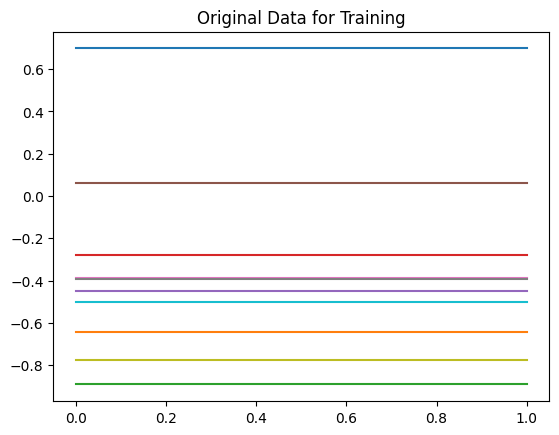

In [3]:
n_samples = 2000
data_matrix = np.zeros((n_samples, n_points))
grid_points = np.linspace(0, 1, n_points)

load_trained = True
train = False
save_model = False

data_matrix = random_state.uniform(
    -1, 1, size =(n_samples, 1),
).repeat(n_points, axis=1)

fd = FDataGrid(data_matrix=data_matrix, grid_points=grid_points)
fig, ax = plt.subplots()
fd[:10].plot(axes=ax)
ax.set_title("Original Data for Training")
plt.show()


##### Fitting and Training the Diffusion Models

In [4]:

from skfda.ml.generative.diffusion_model import FunctionalDiffusionGenerator

non_diag_gen = FunctionalDiffusionGenerator(
    diff_process=non_diag_proc,
    seed=seed,
    device=device,
)
diag_gen = FunctionalDiffusionGenerator(
    diff_process=diag_proc,
    seed=seed,
    device=device,
)


In [5]:
if train:
    _ = non_diag_gen.fit(fd)
    _ = diag_gen.fit(fd)
    if save_model:
        non_diag_gen.save("./models/vp_vs_freq/non_diag_gen_cte.pth")
        diag_gen.save("./models/vp_vs_freq/diag_gen_cte.pth")
elif load_trained:
    non_diag_gen = FunctionalDiffusionGenerator.load(
        "./models/vp_vs_freq/non_diag_gen_cte.pth",
        device=device,
        diff_process=non_diag_proc,
    )
    diag_gen = FunctionalDiffusionGenerator.load(
        "./models/vp_vs_freq/diag_gen_cte.pth",
        device=device,
        diff_process=diag_proc,
    )
else:
    msg = ("You must choose either to train "
           "the generators or to load pre-trained models.")
    raise ValueError(msg)


### Generating the Reverse Evolution

Once the generators are fitted, we can use the `generate_evolution` method to visualize how `n_samples` evolve from pure noise into fully generated samples. This process works by integrating the reverse SDE using the Euler-Maruyama method to systematically undo the noise injection.

It is important to understand how `generate_evolution` handles time stepping. The method applies your defined `n_steps` between each specified frame in your time array. For example, if you want to observe the process at $t=[0,0.5,1]$ and set `n_steps=1000`, the integrator will take 1,000 steps from $t=0$ to $t=0.5$, and another 1,000 steps from $t=0.5$ to $t=1$.

To keep computation times reasonable in this notebook, we use a more efficient step schedule:

- We discretize the total time into **25 frames**.
- We set the integrator to take only **20 steps** between each frame.

This approach results in a total of **500 integration** steps from $t=1$ down to $t=0$. It provides a fast generation process while still maintaining enough resolution to visualize the reverse diffusion smoothly.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc
from matplotlib.animation import FuncAnimation

from skfda.ml.generative.reverse_diffusion import (
    EulerMaruyamaIntegrator,
    SDEReverseDiffusionProcess,
)

n_frames = 25
# More frames near 0.0 for better visualization
timesteps = np.linspace(1.0, 0.0, n_frames)**2
n_frames = len(timesteps)
n_samples_to_plot = 1  # Choose how many generated samples to visualize

f_data_evo_1 = non_diag_gen.generate_evolution(
    timesteps=timesteps,
    n_samples=n_samples_to_plot,
        reverse_process=SDEReverseDiffusionProcess(
            EulerMaruyamaIntegrator(
                n_steps=20,
                seed=seed,
                device=device,
            ),
        ),
)
f_data_evo_2 = diag_gen.generate_evolution(
    timesteps=timesteps,
    n_samples=n_samples_to_plot,
    reverse_process=SDEReverseDiffusionProcess(
        EulerMaruyamaIntegrator(
            n_steps=20,
            seed=seed,
            device=device,
        ),
    ),
)

fd_min = min(
    f_data_evo_1[0].data_matrix.min(),
    f_data_evo_2[0].data_matrix.min(),
)
fd_max = max(f_data_evo_1[0].data_matrix.max(),
             f_data_evo_2[0].data_matrix.max(),
        )

f_data_evolutions = [f_data_evo_1, f_data_evo_2]
model_names = ["Circulant", "VP"]

fig_gen, axes_gen = plt.subplots(1, 2, figsize=(12, 5))
rc("animation", html="jshtml")
# Extract grid points for plotting
x_data = f_data_evolutions[0][0].grid_points[0]

lines_per_ax = [[], []]
for i, ax in enumerate(axes_gen):
    for j in range(n_samples_to_plot):
        color = f"C{(j+i*n_samples_to_plot)%10}" # Cycle through colors
        line, = ax.plot([], [], lw=2, color=color, alpha=0.7)
        lines_per_ax[i].append(line)

    ax.set_xlim(x_data.min(), x_data.max())
    # This numbers might change depending on the data and the process.
    ax.set_ylim(fd_min*0.8 if fd_min > 0 else fd_min * 1.2, fd_max*1.2)


    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{model_names[i]} t=1.000", fontsize=16)

def update(frame: int) -> None:
    """Creation of each frame of the animation."""
    t = timesteps[frame]

    # Iterate over both models/axes
    for i, ax in enumerate(axes_gen):
        # Get the FDataGrid for the current model at the current frame
        current_fdata = f_data_evolutions[i][frame]
        y_data = current_fdata.data_matrix[..., 0]

        # Update the lines for this specific subplot
        for j, line in enumerate(lines_per_ax[i]):
            line.set_data(x_data, y_data[j])

        # Actualizar el título manteniendo el tamaño grande
        ax.set_title(f"{model_names[i]} t={t:.3f}", fontsize=18)

# Create the animation
anim = FuncAnimation(fig_gen, update, frames=n_frames, interval=100)

plt.close()
anim

### Generating Samples

After visualizing the reverse evolution, we can generate a larger number of samples (e.g., `n_samples=100`) to perform a more comprehensive evaluation of the generated data. This will allow us to compare the quality of samples produced by both the standard VP and the non-diagonal processes using quantitative metrics.

In [7]:
n_gen_samples = 100

non_diag_gen_generated = non_diag_gen.generate(n_gen_samples)
diag_gen_generated = diag_gen.generate(n_gen_samples)

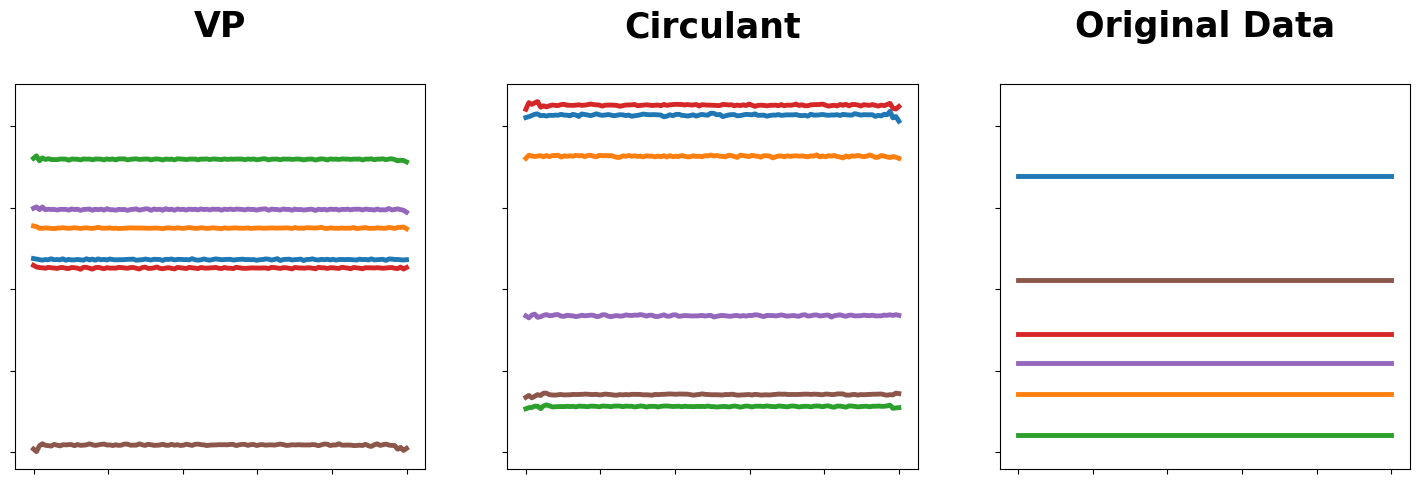

In [8]:

fig_final, axes_final = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
n_gen_to_plot = 6

diag_gen_generated[:n_gen_to_plot].plot(axes=axes_final[0], lw=3.5)
non_diag_gen_generated[:n_gen_to_plot].plot(axes=axes_final[1], lw=3.5)
fd[:n_gen_to_plot].plot(axes=axes_final[2], lw=3.5)

axes_final[0].set_title("VP\n", fontsize=25, fontweight='bold')
axes_final[1].set_title("Circulant\n", fontsize=25, fontweight='bold')
axes_final[2].set_title("Original Data\n", fontsize=25, fontweight='bold')

for ax in axes_final:
    # delete ticks
    ax.tick_params(axis='both', labelbottom=False, labelleft=False)

plt.show()



While visual inspection is helpful, quantitative metrics provide a more rigorous way to compare the samples generated by both methods. 

### Evaluation Metrics for Constant Functions

Let $\{X_i\}_{i=1}^{N}$ be the generated samples evaluated on a grid of $M$ points,
so $X_i = (X_i(t_1), \ldots, X_i(t_M)) \in \mathbb{R}^M$.
Each generated function should approximate a constant, so we summarise it by its
empirical mean $\hat{c}_i = \frac{1}{M}\sum_{j=1}^{M} X_i(t_j)$.

#### Metric 1: Value Diversity (Wasserstein Distance).
A well-trained model should produce constants $\hat{c}_i$ that cover the theoretical
range $[-1, 1]$ uniformly. We quantify this by the Wasserstein-1 distance between the
empirical distribution of $\{\hat{c}_i\}_{i=1}^N$ and the ideal uniform distribution
$\mathcal{U}(-1,1)$:
$$
    W_1\!\left(\hat{\mu},\, \mathcal{U}(-1,1)\right)
    = \int_{\mathbb{R}} \left|F_{\hat{\mu}}(x) - F_{\mathcal{U}}(x)\right| dx,
$$
where $F_{\hat{\mu}}$ and $F_{\mathcal{U}}$ are the cumulative distribution functions
of the empirical and uniform distributions, respectively.
A value close to $0$ indicates that the model generates constants with the correct diversity.
We use the `scipy.stats.wasserstein_distance` function to compute this metric.

#### Metric 2: Internal Noise (MSE Distribution).
Since each generated function should be *exactly* constant, any variation along
the grid is spurious noise introduced by the model. For each sample we compute the
Mean Square Error with respect to its own mean:
$$
    \mathrm{MSE}_i
    = \frac{1}{M} \sum_{j=1}^{M} \bigl(X_i(t_j) - \hat{c}_i\bigr)^2.
$$
We report the distribution of $\{\mathrm{MSE}_i\}_{i=1}^N$, summarised by its median.
Values close to $0$ indicate that the generated functions are smooth and free of noise.

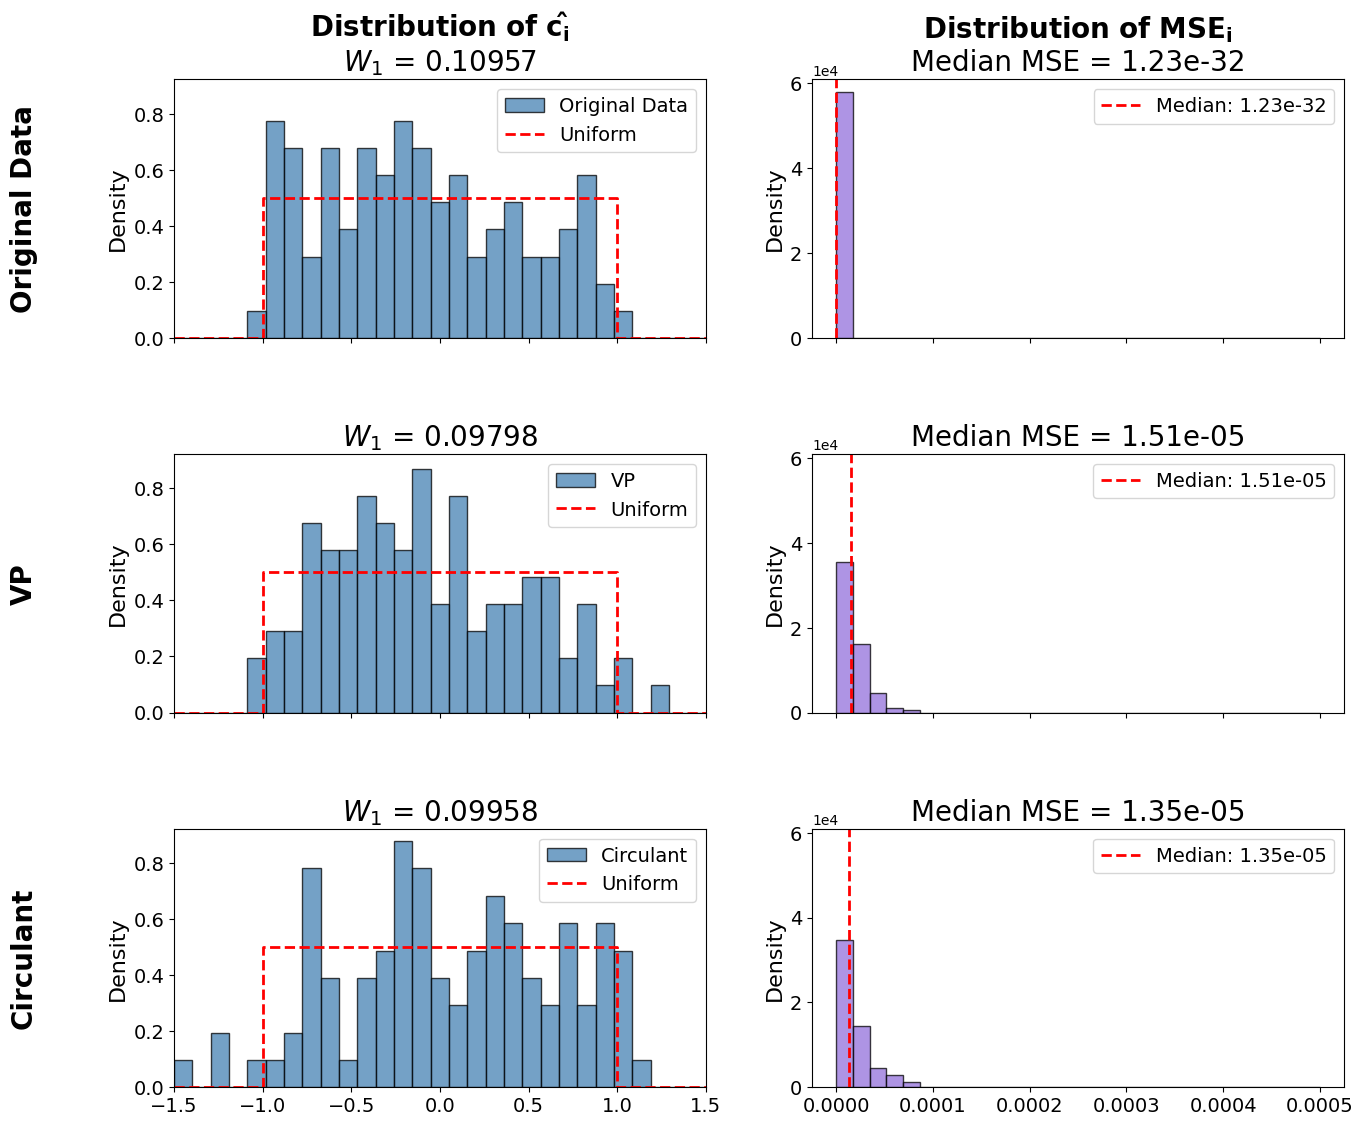

Constant dataset results:
  Original Data: W : 0.109571 | Median MSE: 1.23e-32
  VP: W : 0.097983 | Median MSE: 1.51e-05
  Circulant: W : 0.099579 | Median MSE: 1.35e-05


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
def evaluate_constant_model(fd_gen_dict, theoretical_range=(-1, 1)):
    n_models = len(fd_gen_dict)
    model_names = list(fd_gen_dict.keys())

    fig, axes = plt.subplots(
        n_models, 2,
        figsize=(15, 4 * n_models),
        sharey="col", sharex="col",
        squeeze=False,
    )

    # ── Column titles (row 0 only, bold, large) ──────────────────────────────
    col_titles = ["Constants Distribution", "Internal Noise (MSE)"]
    for col, col_title in enumerate(col_titles):
        axes[0, col].set_title(
            col_title, fontsize=20, fontweight="bold", pad=10
        )

    distribution_bins = np.linspace(
        theoretical_range[0] - 0.5,
        theoretical_range[1] + 0.5,
        30,
    )

    error_bins  = np.linspace(0, 0.0005, 30)
    result_dict = {}

    for row, (model_name, fd_gen) in enumerate(fd_gen_dict.items()):
        y_gen = fd_gen.data_matrix.squeeze(-1)
        N, M  = y_gen.shape

        # ── Metric 1: Value Distribution (Wasserstein) ───────────────────────
        empirical_means = np.mean(y_gen, axis=1)
        ideal_means     = np.linspace(
            theoretical_range[0],
            theoretical_range[1],
            N,
        )

        w1= wasserstein_distance(empirical_means, ideal_means)

        # ── Metric 2: Internal Noise (MSE) ───────────────────────────────────
        residuals    = y_gen - empirical_means[:, None]
        internal_mse = np.mean(residuals**2, axis=1)
        median_mse   = np.median(internal_mse)

        # ── Col 0 — Histogram of means ───────────────────────────────────────
        theoretical_height = (1.0 / 
                              (theoretical_range[1] - theoretical_range[0])
                             )
        x_unif = [
            theoretical_range[0] - 0.5,
            theoretical_range[0],
            theoretical_range[0],
            theoretical_range[1],
            theoretical_range[1],
            theoretical_range[1] + 0.5,
        ]

        y_unif = [0, 0, theoretical_height, theoretical_height, 0, 0]

        ax0 = axes[row, 0]
        ax0.hist(
            empirical_means, bins=distribution_bins, density=True,
            alpha=0.75, color="steelblue", edgecolor="black", label=model_name,
                )
        ax0.plot(
            x_unif, y_unif, color="red", linestyle="--",
            linewidth=2, label="Uniform",
        )

        ax0.set_xlim(theoretical_range[0] - 0.5, theoretical_range[1] + 0.5)
        ax0.set_ylabel("Density", fontsize=16)
        ax0.legend(fontsize=14)
        ax0.tick_params(axis="both", labelsize=14)

        # Row 0: bold column name + metric; other rows: metric only
        title_w = (
            r"$\bf{Distribution\ of\ \hat{c_i}}$" + f"\n$W_1$ = {w1:.5f}"
            if row == 0 else
            f"$W_1$ = {w1:.5f}"
        )
        ax0.set_title(title_w, fontsize=20)

        # ── Col 1 — Histogram of MSE ─────────────────────────────────────────
        ax1 = axes[row, 1]
        ax1.hist(internal_mse, bins=error_bins, density=True,
                 alpha=0.75, color="mediumpurple", edgecolor="black")
        ax1.axvline(median_mse, color="red", linestyle="--", linewidth=2,
                    label=f"Median: {median_mse:.2e}")
        ax1.set_ylabel("Density", fontsize=16)
        ax1.legend(fontsize=14)
        ax1.tick_params(axis="both", labelsize=14)
        ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
        title_mse = (
            r"$\bf{Distribution\ of\ MSE_i}$" + f"\nMedian MSE = {median_mse:.2e}"
            if row == 0 else
            f"Median MSE = {median_mse:.2e}"
        )
        ax1.set_title(title_mse, fontsize=20)

        result_dict[model_name] = {
            "wasserstein_distance": w1,
            "median_mse":           median_mse,
        }

    # ── Row labels on the left (same pattern as the reference code) ──────────
    fig.subplots_adjust(left=0.12, top=0.95, hspace=0.45)
    fig.canvas.draw()  # force layout before computing positions

    for row, name in enumerate(model_names):
        row_y = (axes[row, 0].get_position().y0 + axes[row, 0].get_position().y1) / 2
        fig.text(0.02, row_y, name,
                 va="center", ha="center",
                 fontsize=20, fontweight="bold", rotation=90)

    plt.show()
    return result_dict
# ==========================================

# EXECUTION

# ==========================================

data_dict = {

"Original Data": fd[:n_gen_samples],

"VP": diag_gen_generated,

"Circulant": non_diag_gen_generated,

}


dict_results = evaluate_constant_model(data_dict)

print("Constant dataset results:")
for k,v in dict_results.items():
    print(f"  {k}: W : {v['wasserstein_distance']:.6f} | Median MSE: {v['median_mse']:.2e}")


The mean values of the generated samples show similar distributions for both methods: the mass concentrates near its mean rather than following the target uniform distribution, which reflects the limited capacity of the score network for this small training run.

For the internal noise metric, the non-diagonal VP process tends to produce slightly smoother functions (lower intra-sample MSE) than the standard VP, consistent with the spatial prior introduced by $ L(\tau)$. However, the difference is modest.